# CardioIA — Risk classifier (TF-IDF + Logistic Regression)

Classifies simulated patient sentences as `low risk` or `high risk`.
Academic project with simulated data — not for clinical use.

## 1. Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, classification_report,
                             confusion_matrix, recall_score)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline

RANDOM_STATE = 42
CLASSES = ["low risk", "high risk"]
pd.set_option("display.max_colwidth", 120)

## 2. Loading the risk data

In [2]:
candidates = [Path("../data/text/risk_dataset.csv"), Path("data/text/risk_dataset.csv"), Path("risk_dataset.csv")]
DATASET_PATH = next((p for p in candidates if p.exists()), None)
assert DATASET_PATH is not None, "risk_dataset.csv not found"

df = pd.read_csv(DATASET_PATH, encoding="utf-8")
df["sentence"] = df["sentence"].str.strip()
df["label"] = df["label"].str.strip()
print(f"Total sentences: {len(df)} | duplicates: {df['sentence'].duplicated().sum()}")
df.sample(8, random_state=RANDOM_STATE)

Total sentences: 121 | duplicates: 0


,sentence,label
44,my blood pressure dropped a lot and I am cold and confused,high risk
47,my heart feels like it is going to jump out of my mouth and I am very dizzy,high risk
4,I have intense shortness of breath even while sitting still in the chair,high risk
55,an explosive headache came out of nowhere and my blood pressure is very high,high risk
26,I have strong chest pain with a high fever and a racing heart,high risk
64,I feel a quick twinge in my chest when I stretch but it goes away soon,low risk
73,I would like to renew the prescription for my blood pressure medicine which is under control,low risk
10,my blood pressure read 180 over 120 and I have a terrible headache,high risk


## 3. Class distribution

,count
label,
low risk,61
high risk,60


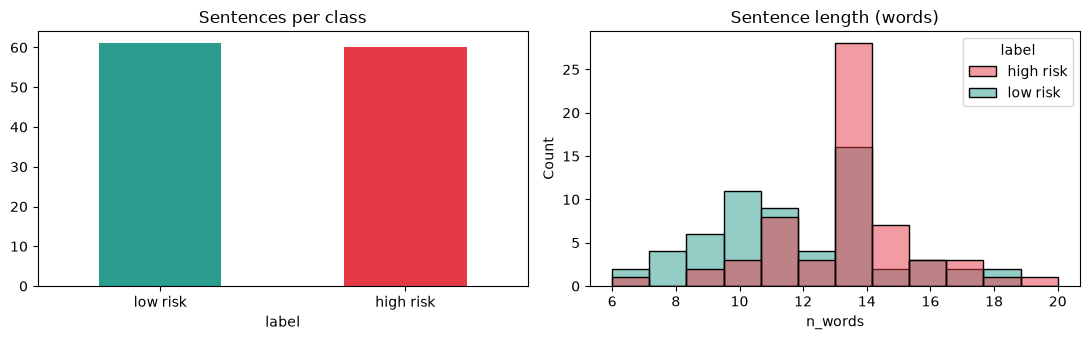

In [3]:
counts = df["label"].value_counts()
display(counts.to_frame("count"))

df["n_words"] = df["sentence"].str.split().str.len()
palette = {"low risk": "#2a9d8f", "high risk": "#e63946"}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
counts.plot.bar(ax=axes[0], color=[palette[c] for c in counts.index], rot=0, title="Sentences per class")
sns.histplot(data=df, x="n_words", hue="label", bins=12, ax=axes[1], palette=palette)
axes[1].set_title("Sentence length (words)")
plt.tight_layout()
plt.show()

## 4. TF-IDF vectorization

TF-IDF turns each sentence into a numeric vector: a term weighs more when it is frequent in the sentence (TF) and rare in the dataset (IDF).
Settings: lowercase, unigrams + bigrams, stopwords kept ("not" and "mild" change the meaning).

In [4]:
vectorizer_demo = TfidfVectorizer(lowercase=True, strip_accents="unicode", ngram_range=(1, 2), sublinear_tf=True)
X_demo = vectorizer_demo.fit_transform(df["sentence"])
print(f"TF-IDF matrix: {X_demo.shape[0]} sentences x {X_demo.shape[1]} terms")

terms = vectorizer_demo.get_feature_names_out()
row = X_demo[0].toarray().ravel()
print("Sentence:", df.loc[0, "sentence"])
pd.DataFrame({"term": terms[row > 0], "tfidf": row[row > 0]}).sort_values("tfidf", ascending=False).head(10).reset_index(drop=True)

TF-IDF matrix: 121 sentences x 1323 terms
Sentence: I have a very strong chest pain that has not gone away for more than twenty minutes


,term,tfidf
0,away for,0.213539
1,has not,0.213539
2,gone away,0.213539
3,gone,0.213539
4,for more,0.213539
5,have very,0.213539
6,than twenty,0.213539
7,twenty minutes,0.213539
8,twenty,0.213539
9,very strong,0.213539


## 5. Train/test split

In [5]:
X_text = df["sentence"]
y = df["label"]

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

vectorizer = TfidfVectorizer(lowercase=True, strip_accents="unicode", ngram_range=(1, 2), sublinear_tf=True)
X_train = vectorizer.fit_transform(X_train_txt)
X_test = vectorizer.transform(X_test_txt)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | Vocabulary: {X_train.shape[1]} terms")

Train: 96 | Test: 25 | Vocabulary: 1116 terms


## 6. Building and training the model

In [6]:
model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## 7. Evaluation

- **Accuracy:** share of correct predictions.
- **Precision:** when the model says "high risk", how often it is right.
- **Recall:** share of the real "high risk" cases the model found.
- **F1:** balance between precision and recall.

In [7]:
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred, labels=CLASSES, digits=3, zero_division=0))

Test accuracy: 0.920

              precision    recall  f1-score   support

    low risk      1.000     0.846     0.917        13
   high risk      0.857     1.000     0.923        12

    accuracy                          0.920        25
   macro avg      0.929     0.923     0.920        25
weighted avg      0.931     0.920     0.920        25



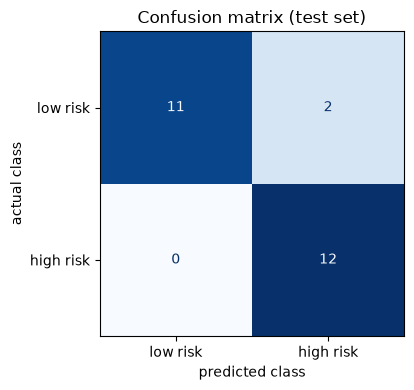

False negatives (high -> low): 0 | False positives (low -> high): 2


In [8]:
cm = confusion_matrix(y_test, y_pred, labels=CLASSES)
fig, ax = plt.subplots(figsize=(4.8, 4))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set(title="Confusion matrix (test set)", xlabel="predicted class", ylabel="actual class")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"False negatives (high -> low): {fn} | False positives (low -> high): {fp}")

## 8. High-risk recall and decision threshold

Missing a severe case (false negative) is worse than a false alarm, so we check how the threshold changes the `high risk` recall.

In [9]:
high_idx = list(model.classes_).index("high risk")
proba_high_test = model.predict_proba(X_test)[:, high_idx]

rows = []
for threshold in [0.3, 0.4, 0.5, 0.6]:
    pred_t = np.where(proba_high_test >= threshold, "high risk", "low risk")
    cm_t = confusion_matrix(y_test, pred_t, labels=CLASSES)
    rows.append({
        "threshold": threshold,
        "high risk recall": recall_score(y_test, pred_t, pos_label="high risk"),
        "false negatives": cm_t[1, 0],
        "false positives": cm_t[0, 1],
        "accuracy": accuracy_score(y_test, pred_t),
    })
pd.DataFrame(rows).round(3)

,threshold,high risk recall,false negatives,false positives,accuracy
0,0.3,1.0,0,13,0.48
1,0.4,1.0,0,7,0.72
2,0.5,1.0,0,2,0.92
3,0.6,0.5,6,0,0.76


## 9. Cross-validation (5 folds)

In [10]:
pipeline = make_pipeline(
    TfidfVectorizer(lowercase=True, strip_accents="unicode", ngram_range=(1, 2), sublinear_tf=True),
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
acc_cv = cross_val_score(pipeline, X_text, y, cv=cv, scoring="accuracy")
rec_cv = cross_val_score(pipeline, X_text, (y == "high risk").astype(int), cv=cv, scoring="recall")
print("Accuracy per fold:          ", np.round(acc_cv, 3), f"-> mean {acc_cv.mean():.3f} (+/- {acc_cv.std():.3f})")
print("Recall (high risk) per fold:", np.round(rec_cv, 3), f"-> mean {rec_cv.mean():.3f} (+/- {rec_cv.std():.3f})")

Accuracy per fold:           [0.92  0.958 0.708 0.833 0.917] -> mean 0.867 (+/- 0.089)
Recall (high risk) per fold: [0.917 0.917 0.917 0.917 0.833] -> mean 0.900 (+/- 0.033)


## 10. Most important terms

In [11]:
sign = 1 if model.classes_[1] == "high risk" else -1
weights_high = sign * model.coef_[0]
terms = vectorizer.get_feature_names_out()
order = np.argsort(weights_high)
top = 12
pd.DataFrame({
    "terms -> high risk": terms[order[::-1][:top]],
    "weight": weights_high[order[::-1][:top]].round(3),
    "terms -> low risk": terms[order[:top]],
    "weight ": weights_high[order[:top]].round(3),
})

,terms -> high risk,weight,terms -> low risk,weight
0,and,0.983,after,-0.788
1,chest,0.612,mild,-0.483
2,chest pain,0.601,little,-0.474
3,very,0.462,want,-0.423
4,shortness,0.427,when,-0.404
5,shortness of,0.427,have,-0.366
6,heart,0.387,want to,-0.363
7,of breath,0.386,bit,-0.329
8,breath,0.386,normal,-0.317
9,and am,0.374,have mild,-0.315


Words with no clinical meaning (e.g., "and", "after", "want") are among the strongest weights: the model learns writing patterns, not medicine.

## 11. Testing new sentences

In [12]:
new_sentences = [
    "I have a strong chest pain that started half an hour ago and is not improving",
    "I have a mild pain in my legs after cycling on the weekend",
    "my husband fainted in the kitchen and is having trouble breathing",
    "I want to book a routine appointment for next month",
    "I am short of breath and my lips are turning purple",
    "I had a bit of a headache after spending too much time at the computer",
    "my heart is beating out of rhythm and I feel I am going to black out",
    "I have a runny nose and have been sneezing since yesterday",
    "I feel a tightness in my chest that goes to my neck and I am nauseous",
    "my blood pressure was fine at the last check and I feel energetic",
    "I am tired",
    "I have chest pain",
]

proba_new = model.predict_proba(vectorizer.transform(new_sentences))[:, high_idx]
for sentence, p in zip(new_sentences, proba_new):
    label = "HIGH RISK" if p >= 0.5 else "LOW RISK"
    print(f"Sentence: {sentence}\nClassification: {label} | Probability of high risk: {p:.1%}\n")

Sentence: I have a strong chest pain that started half an hour ago and is not improving
Classification: HIGH RISK | Probability of high risk: 67.0%

Sentence: I have a mild pain in my legs after cycling on the weekend
Classification: LOW RISK | Probability of high risk: 33.4%

Sentence: my husband fainted in the kitchen and is having trouble breathing
Classification: HIGH RISK | Probability of high risk: 59.7%

Sentence: I want to book a routine appointment for next month
Classification: LOW RISK | Probability of high risk: 36.0%

Sentence: I am short of breath and my lips are turning purple
Classification: HIGH RISK | Probability of high risk: 63.1%

Sentence: I had a bit of a headache after spending too much time at the computer
Classification: LOW RISK | Probability of high risk: 34.1%

Sentence: my heart is beating out of rhythm and I feel I am going to black out
Classification: HIGH RISK | Probability of high risk: 65.6%

Sentence: I have a runny nose and have been sneezing since 

## 12. Limitations and possible biases

- **Small dataset** (121 sentences): metrics vary a lot between splits.
- **Artificial sentences** written by one person, with limited vocabulary.
- **Balanced classes by design**, unlike real triage, where high-risk cases are rare.
- **Language bias:** the model relies on words like "mild" and "strong" and on writing style.
- **No demographic diversity** (age, sex, region, education).
- **Risk of overfitting** with many terms and few examples.
- **False negatives** (severe case classified as low risk) are the most dangerous error; **false positives** cause unnecessary alarms.
- **Text classification is not a medical diagnosis**, and the output must never be trusted blindly.